# <font color="dodgerblue">Sentiment Analysis of YouTube Comments with Twitter-RoBERTa</font>

This notebook fine-tunes `cardiffnlp/twitter-roberta-base-sentiment-latest` to classify YouTube comments as **Negative**, **Neutral**, or **Positive**.

## <font color="gray"> Summary </font>

- Dataset: deterministic 100,000-row sample from a public 1.03M-comments dataset.
- Preprocessing: language detection, selective translation to English, URL and mention normalization, and emoji demojization.
- Model: Twitter-RoBERTa, with embeddings and the first four encoder layers frozen.
- Test results: **75.99% accuracy** and **0.7597 macro F1**.

The final evaluation output is preserved from the completed Colab run summarized in the accompanying PDF. Expensive stages use local caches when available.

## <font color="gray"> Context  </font>

The objective is to adapt a sentiment model trained on social-media language to YouTube comments. The original workflow is preserved: sample the data, selectively translate non-English comments, preprocess the text, fine-tune for three epochs, and evaluate on a stratified 80/20 split.

### <font color="gray"> Key assumptions </font>

- The upstream dataset labels combine automated labeling and manual validation.
- The translation cache belongs to the exact deterministic sample defined below.
- A random row-level split measures performance on comments from the same overall source distribution (it is not a strict test on unseen videos).
- The dataset contains augmented and repeated comments, so the reported result should be interpreted as a portfolio experiment rather than a production benchmark.

## 1. Setup

Install the dependencies once from the repository root:

```bash
python -m pip install -r requirements.txt
```

The dataset is currently public, so no Hugging Face token is embedded or required. If authentication is ever needed, use `huggingface_hub.login()` without passing a token literal.

In [ ]:
from __future__ import annotations

import hashlib
import json
import random
import re
import time
import urllib.request
from pathlib import Path

import emoji
import fasttext
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from deep_translator import GoogleTranslator
from huggingface_hub import hf_hub_download
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm
from transformers import AutoModelForSequenceClassification, AutoTokenizer, get_scheduler

In [ ]:
# Reproducible project configuration
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name in {"notebook", "notebooks"}:
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data" / "processed"
ARTIFACTS_DIR = PROJECT_ROOT / "artifacts"
EXTRAS_DIR = PROJECT_ROOT / "extras"  # Local only (ignored by git)
MODEL_DIR = EXTRAS_DIR / "model_checkpoint"
TRANSLATION_CACHE = DATA_DIR / "sentiments_translated.csv"
PREDICTIONS_PATH = EXTRAS_DIR / "test_predictions_ROBERTA_translated.csv"
FASTTEXT_MODEL_PATH = EXTRAS_DIR / "lid.176.bin"

for directory in (DATA_DIR, ARTIFACTS_DIR, EXTRAS_DIR):
    directory.mkdir(parents=True, exist_ok=True)

SEED = 42
SAMPLE_SIZE = 100_000
TEST_SIZE = 0.20
EPOCHS = 3
BATCH_SIZE = 16
MAX_LENGTH = 128

DATASET_REPO = "AmaanP314/youtube-comment-sentiment"
DATASET_FILENAME = "youtube-comments-sentiment.csv"
DATASET_REVISION = "main"
# The checksum below pins the exact CSV content used even if the branch changes.
DATASET_SHA256 = "368b41f5675f0bd2313ab41c7f524489c54cb8792e31e24a87091c70c118c3fe"
MODEL_NAME = "cardiffnlp/twitter-roberta-base-sentiment-latest"

# Set either flag to True only when intentionally regenerating an expensive artifact.
FORCE_RETRANSLATE = False
FORCE_RETRAIN = False

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

## 2. Data

The source contains 1,032,225 YouTube comments with three sentiment labels and additional video, author, engagement, date, country, and category metadata. This experiment retains only comment text and sentiment after drawing the deterministic sample.

Source: [YouTube Comments Sentiment Analysis Dataset](https://huggingface.co/datasets/AmaanP314/youtube-comment-sentiment).

In [ ]:
dataset_path = Path(
    hf_hub_download(
        repo_id=DATASET_REPO,
        filename=DATASET_FILENAME,
        repo_type="dataset",
        revision=DATASET_REVISION,
    )
)

dataset_digest = hashlib.sha256(dataset_path.read_bytes()).hexdigest()
if dataset_digest != DATASET_SHA256:
    raise ValueError("The downloaded dataset does not match the version used in this project.")

source_df = pd.read_csv(dataset_path)
print(f"Source shape: {source_df.shape}")

df = (
    source_df[["CommentText", "Sentiment"]]
    .sample(SAMPLE_SIZE, random_state=SEED)
    .copy()
)

display(df.head(3))
display(
    pd.DataFrame(
        {
            "rows": [len(df)],
            "average_words_per_comment": [df["CommentText"].fillna("").str.split().str.len().mean()],
            "missing_comments": [df["CommentText"].isna().sum()],
        }
    ).round(2)
)
display(df["Sentiment"].value_counts(normalize=True).rename("share").to_frame())

## 3. Detect and translate non-English comments

FastText identifies the likely language and its confidence. The original translation rule is retained: English comments are not translated, and uncertain non-English comments containing emojis are also left unchanged. The checked-in translation cache makes the normal run fast, regeneration can take roughly two hours and depends on an external translation service.

In [ ]:
FASTTEXT_URL = "https://dl.fbaipublicfiles.com/fasttext/supervised-models/lid.176.bin"
if not FASTTEXT_MODEL_PATH.exists():
    urllib.request.urlretrieve(FASTTEXT_URL, FASTTEXT_MODEL_PATH)

language_model = fasttext.load_model(str(FASTTEXT_MODEL_PATH))


def detect_language(text: object) -> tuple[str, float]:
    clean_text = "" if pd.isna(text) else str(text).replace("\n", " ").strip()
    if not clean_text:
        return "unknown", 0.0
    labels, confidences = language_model.predict(clean_text)
    return labels[0].replace("__label__", ""), float(confidences[0])


def has_emoji(text: object) -> bool:
    clean_text = "" if pd.isna(text) else str(text)
    return any(character in emoji.EMOJI_DATA for character in clean_text)


df[["Language", "LangConf"]] = df["CommentText"].apply(
    lambda value: pd.Series(detect_language(value))
)
df["HasEmoji"] = df["CommentText"].apply(has_emoji)
df["Translate"] = np.where(
    (df["Language"] == "en")
    | ((df["Language"] != "en") & df["HasEmoji"] & (df["LangConf"] < 0.5)),
    False,
    True,
)

language_summary = pd.DataFrame(
    {
        "non_english_share": [(df["Language"] != "en").mean()],
        "translation_candidate_share": [df["Translate"].mean()],
    }
)
display(language_summary.style.format("{:.1%}"))

In [ ]:
def build_translation_cache(candidates: pd.DataFrame, output_path: Path) -> pd.DataFrame:
    translated_df = candidates.copy()
    translated_df["index"] = translated_df.index
    translated_df["translated"] = pd.NA

    for position, idx in enumerate(tqdm(translated_df.index, desc="Translating comments"), start=1):
        comment = str(translated_df.at[idx, "CommentText"])
        try:
            translated_df.at[idx, "translated"] = GoogleTranslator(
                source="auto", target="en"
            ).translate(comment)
        except Exception:
            # Preserve a missing value instead of inserting the word "ERROR" into training data.
            translated_df.at[idx, "translated"] = pd.NA

        time.sleep(0.5)
        if position % 250 == 0:
            translated_df.to_csv(output_path, index=False)

    translated_df.to_csv(output_path, index=False)
    return translated_df


translation_candidates = df[df["Translate"]].copy()
if FORCE_RETRANSLATE or not TRANSLATION_CACHE.exists():
    translated = build_translation_cache(translation_candidates, TRANSLATION_CACHE)
else:
    translated = pd.read_csv(TRANSLATION_CACHE)

valid_translation = (
    translated["translated"].notna()
    & translated["translated"].astype(str).str.strip().ne("")
    & translated["translated"].astype(str).str.upper().ne("ERROR")
)
translated_valid = translated.loc[valid_translation].copy()
translated_valid["index"] = translated_valid["index"].astype(int)

# The cached row index is safe only if its original text still matches the sampled source row.
cached_source_matches = (
    df.loc[translated_valid["index"], "CommentText"].astype(str).to_numpy()
    == translated_valid["CommentText"].astype(str).to_numpy()
)
if not cached_source_matches.all():
    raise ValueError("Translation cache does not match the pinned dataset sample.")

df.loc[translated_valid["index"], "CommentText"] = translated_valid["translated"].to_numpy()

print(f"Translation candidates: {len(translated):,}")
print(f"Valid cached translations applied: {len(translated_valid):,}")
print(f"Unavailable translations retained in their original language: {(~valid_translation).sum():,}")

The original cache contains 6,582 candidates: 6,154 valid translations, 427 missing results, and one failed request recorded as `ERROR`. The failed and missing translations are now retained in their original language rather than being injected into the training text.

## 4. Preprocess and split

RoBERTa requires limited text normalization. URLs are replaced with a stable token, mentions and hashtag markers are removed, emojis are converted to text, and whitespace is normalized. The sentiment labels map to Negative = 0, Neutral = 1, and Positive = 2.

In [ ]:
def preprocess_text(text: object) -> str:
    clean_text = "" if pd.isna(text) else str(text)
    clean_text = clean_text.lower()
    clean_text = re.sub(r"http\S+|www\S+|https\S+", "http", clean_text)
    clean_text = re.sub(r"@\w+|#", "", clean_text)
    clean_text = emoji.demojize(clean_text)
    return re.sub(r"\s+", " ", clean_text).strip()


df["CommentText"] = df["CommentText"].apply(preprocess_text)

label_encoder = LabelEncoder()
df["Sentiment"] = label_encoder.fit_transform(df["Sentiment"])
LABEL_NAMES = label_encoder.classes_.tolist()
print(dict(zip(LABEL_NAMES, label_encoder.transform(LABEL_NAMES))))

X_train, X_test, y_train, y_test = train_test_split(
    df["CommentText"].tolist(),
    df["Sentiment"].tolist(),
    test_size=TEST_SIZE,
    random_state=SEED,
    stratify=df["Sentiment"],
)
print(f"Train: {len(X_train):,} | Test: {len(X_test):,}")

## 5. Fine-tune Twitter-RoBERTa

The notebook loads the local checkpoint when it exists. If `extras/model_checkpoint/` has been removed, it reproduces the original three-epoch training run and recreates that ignored local folder. This keeps the published repository small without removing the training logic.

In [ ]:
checkpoint_available = (MODEL_DIR / "model.safetensors").exists()
train_model = FORCE_RETRAIN or not checkpoint_available

tokenizer_source = MODEL_NAME if train_model else str(MODEL_DIR)
tokenizer = AutoTokenizer.from_pretrained(tokenizer_source)


class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=MAX_LENGTH):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            str(self.texts[idx]),
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt",
        )
        return {
            "input_ids": encoding["input_ids"].flatten(),
            "attention_mask": encoding["attention_mask"].flatten(),
            "labels": torch.tensor(self.labels[idx], dtype=torch.long),
        }


train_dataset = TextDataset(X_train, y_train, tokenizer)
test_dataset = TextDataset(X_test, y_test, tokenizer)

loader_generator = torch.Generator().manual_seed(SEED)
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    generator=loader_generator,
)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

if train_model:
    model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=3)
    for parameter in model.roberta.embeddings.parameters():
        parameter.requires_grad = False
    for layer in model.roberta.encoder.layer[:4]:
        for parameter in layer.parameters():
            parameter.requires_grad = False
else:
    model = AutoModelForSequenceClassification.from_pretrained(MODEL_DIR)

model.config.id2label = {index: label.lower() for index, label in enumerate(LABEL_NAMES)}
model.config.label2id = {label.lower(): index for index, label in enumerate(LABEL_NAMES)}
model = model.to(DEVICE)
print("Mode:", "train from base model" if train_model else "load local checkpoint")

In [ ]:
def train_one_epoch(model, loader, optimizer, scheduler, device):
    model.train()
    total_loss = 0.0

    for batch in tqdm(loader, desc="Training", leave=False):
        optimizer.zero_grad()
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        logits = model(input_ids=input_ids, attention_mask=attention_mask).logits
        loss = nn.CrossEntropyLoss()(logits, labels)
        loss.backward()
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()

    return total_loss / len(loader)


if train_model:
    optimizer = torch.optim.AdamW(
        (parameter for parameter in model.parameters() if parameter.requires_grad),
        lr=3e-5,
    )
    training_steps = len(train_loader) * EPOCHS
    scheduler = get_scheduler(
        "linear",
        optimizer=optimizer,
        num_warmup_steps=0,
        num_training_steps=training_steps,
    )

    training_losses = []
    for epoch in range(EPOCHS):
        epoch_loss = train_one_epoch(model, train_loader, optimizer, scheduler, DEVICE)
        training_losses.append(epoch_loss)
        print(f"Epoch {epoch + 1}/{EPOCHS} - loss: {epoch_loss:.4f}")

    MODEL_DIR.mkdir(parents=True, exist_ok=True)
    model.save_pretrained(MODEL_DIR)
    tokenizer.save_pretrained(MODEL_DIR)
    print(f"Checkpoint saved locally to: {MODEL_DIR}")

Recorded training losses from the completed experiment were **0.6274**, **0.4974**, and **0.3684** across the three epochs. Verbose download logs and progress bars are intentionally omitted from the portfolio version.

## 6. Evaluation

Test Accuracy: 75.99%
F1 Score (macro): 0.7597
Recall (macro): 0.7598
Precision (macro): 0.7600


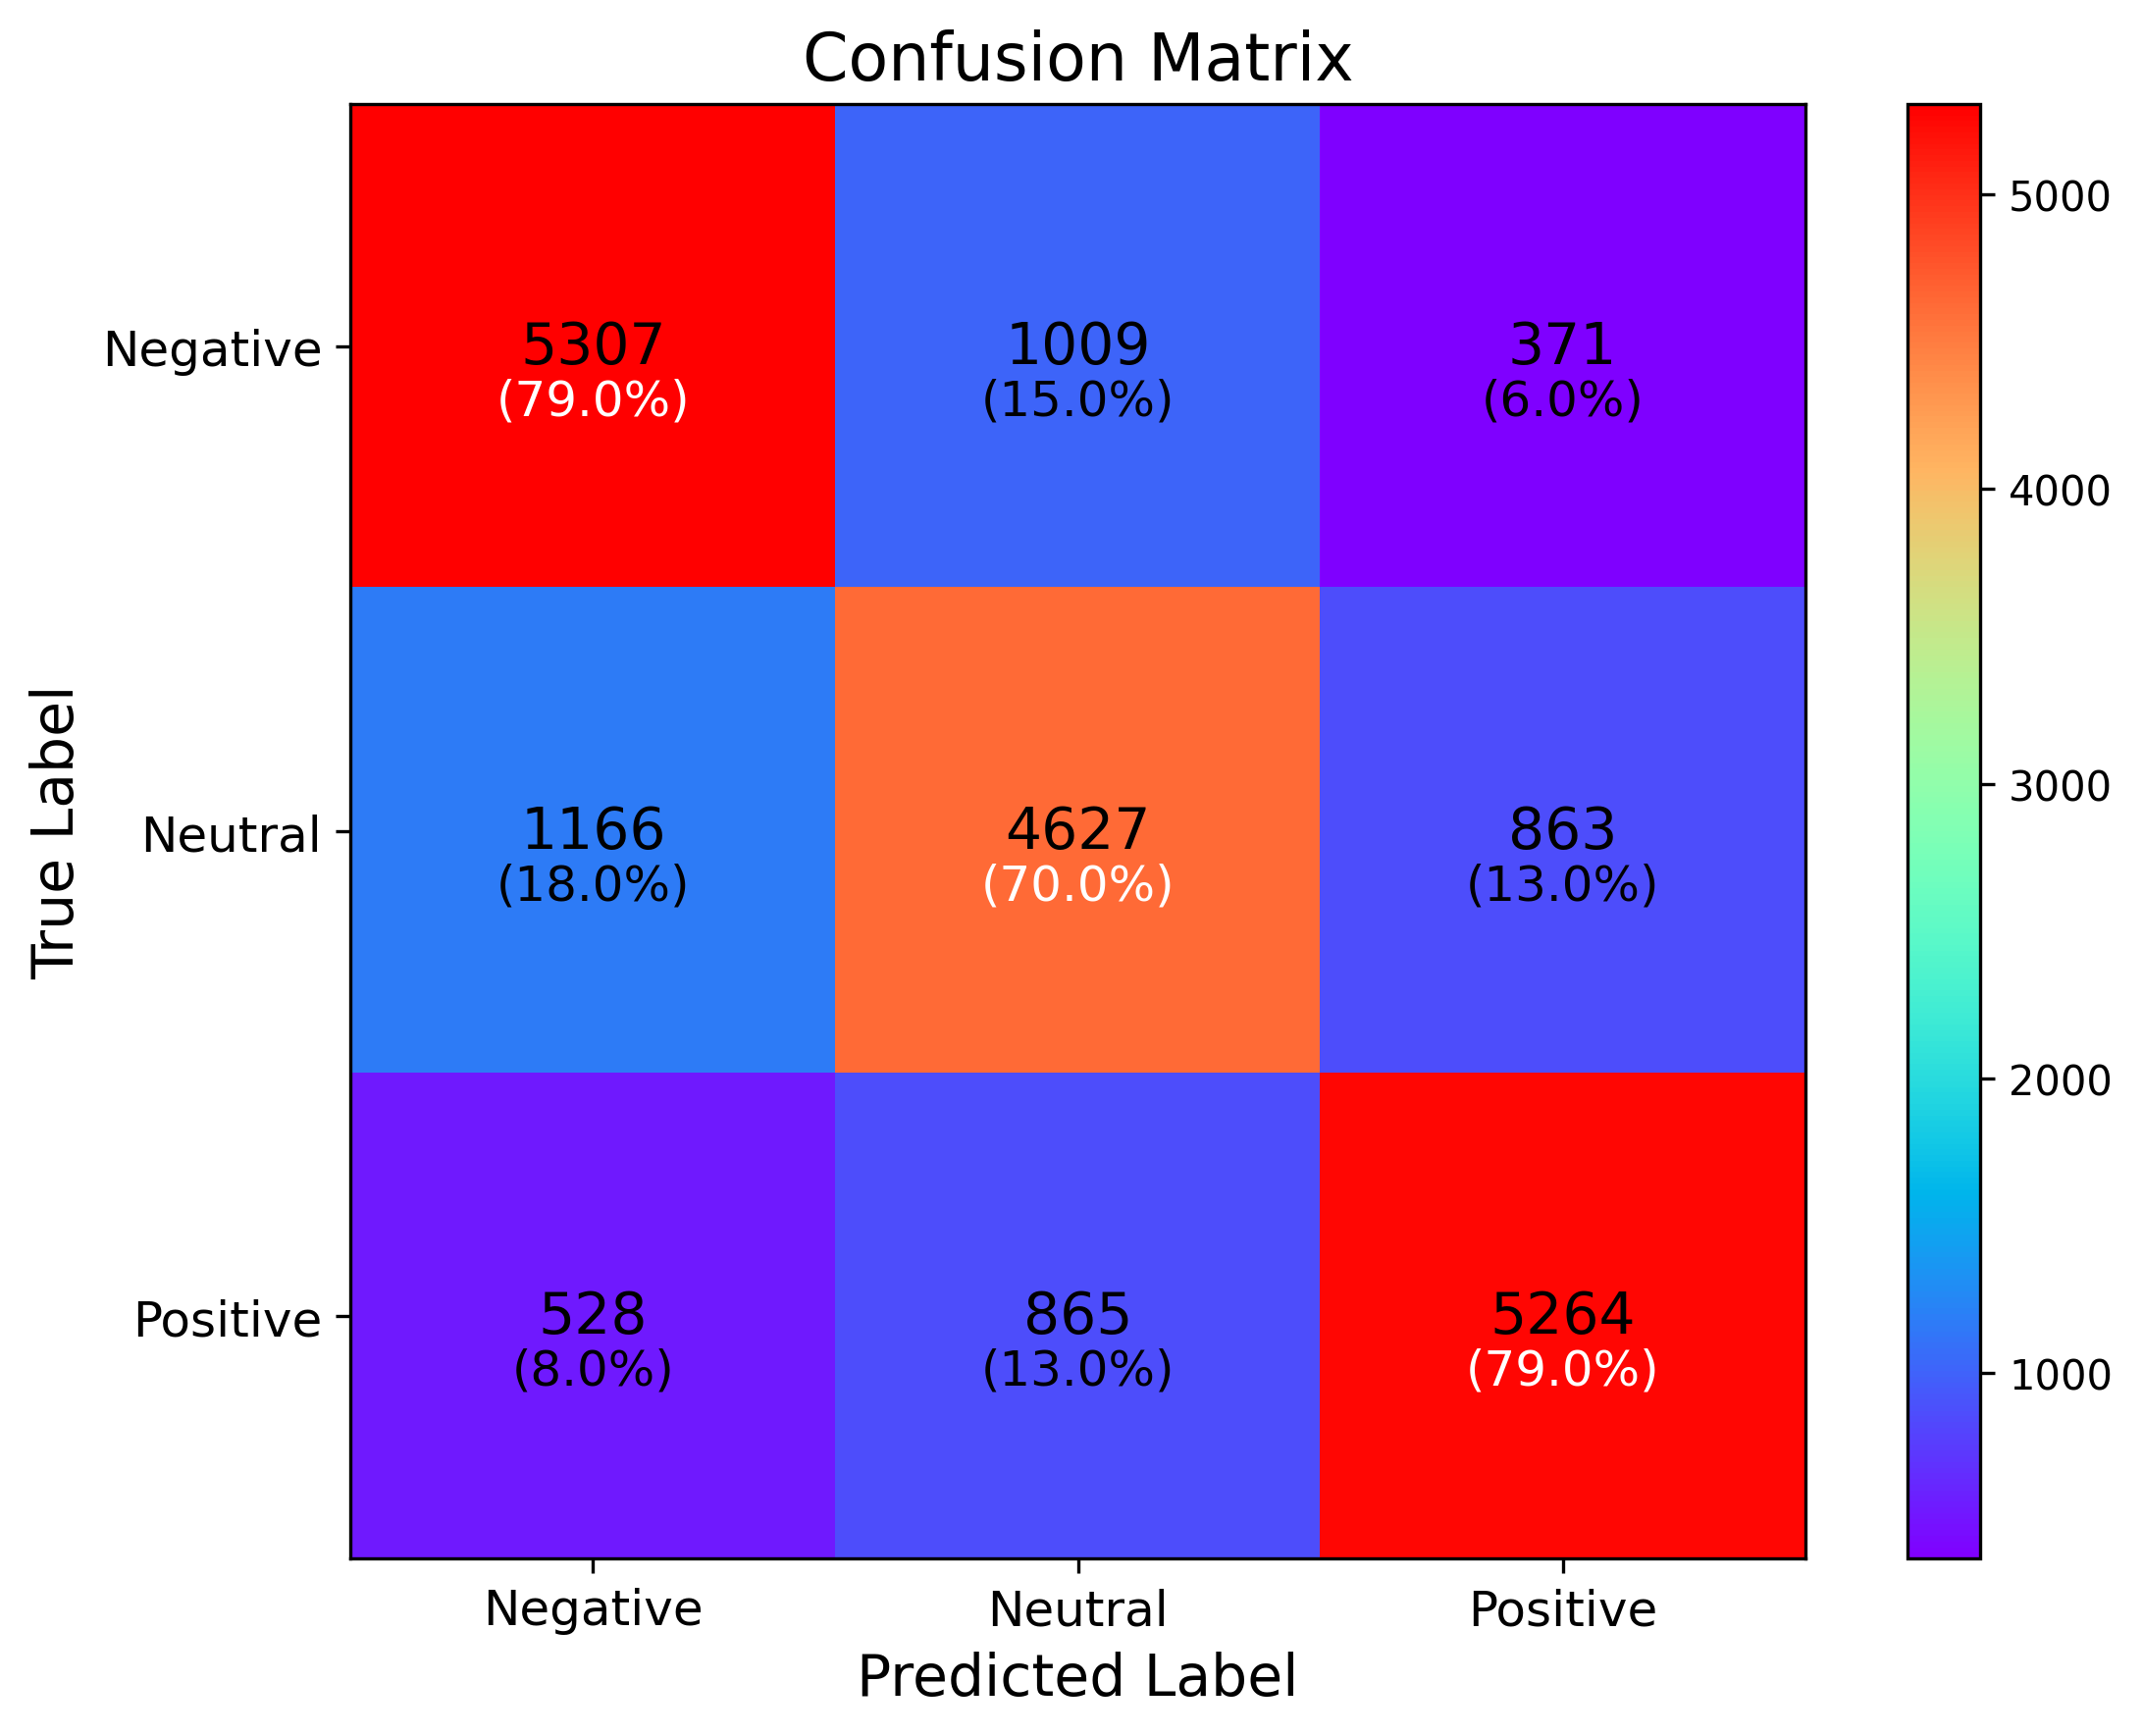

Classification report:
              precision    recall  f1-score   support

           0       0.76      0.79      0.78      6687
           1       0.71      0.70      0.70      6656
           2       0.81      0.79      0.80      6657

    accuracy                           0.76     20000
   macro avg       0.76      0.76      0.76     20000
weighted avg       0.76      0.76      0.76     20000



In [ ]:
def evaluate(model, loader, device):
    model.eval()
    predictions = []
    true_labels = []

    with torch.no_grad():
        for batch in tqdm(loader, desc="Evaluating", leave=False):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            logits = model(input_ids=input_ids, attention_mask=attention_mask).logits
            predictions.extend(torch.argmax(logits, dim=1).cpu().numpy())
            true_labels.extend(labels.cpu().numpy())

    accuracy = accuracy_score(true_labels, predictions)
    macro_f1 = f1_score(true_labels, predictions, average="macro")
    macro_recall = recall_score(true_labels, predictions, average="macro")
    macro_precision = precision_score(true_labels, predictions, average="macro")

    print(f"Test Accuracy: {accuracy * 100:.2f}%")
    print(f"F1 Score (macro): {macro_f1:.4f}")
    print(f"Recall (macro): {macro_recall:.4f}")
    print(f"Precision (macro): {macro_precision:.4f}")

    matrix = confusion_matrix(true_labels, predictions)
    row_percentages = matrix / matrix.sum(axis=1, keepdims=True)

    fig, ax = plt.subplots(figsize=(8, 6), dpi=150)
    sns.heatmap(
        matrix,
        annot=True,
        fmt="d",
        cmap="rainbow",
        xticklabels=LABEL_NAMES,
        yticklabels=LABEL_NAMES,
        ax=ax,
    )
    for row in range(matrix.shape[0]):
        for column in range(matrix.shape[1]):
            ax.text(
                column + 0.5,
                row + 0.68,
                f"({row_percentages[row, column]:.1%})",
                ha="center",
                va="center",
                color="white" if row_percentages[row, column] > 0.3 else "black",
                fontsize=9,
            )

    ax.set_title("Confusion Matrix")
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")
    fig.tight_layout()
    fig.savefig(ARTIFACTS_DIR / "confusion_matrix.png", dpi=300, bbox_inches="tight")
    plt.show()

    print(f"Classification report:\n{classification_report(true_labels, predictions)}")
    return predictions


predictions = evaluate(model, test_loader, DEVICE)

In [ ]:
# Store bulky row-level predictions locally 
predicted_labels = label_encoder.inverse_transform(predictions)
true_test_labels = label_encoder.inverse_transform(y_test)
test_predictions = pd.DataFrame(
    {
        "CommentText": X_test,
        "Sentiment": true_test_labels,
        "Predicted_Sentiment": predicted_labels,
    }
)
test_predictions.to_csv(PREDICTIONS_PATH, index=False)

metrics = {
    "accuracy": accuracy_score(true_test_labels, predicted_labels),
    "macro_f1": f1_score(true_test_labels, predicted_labels, average="macro"),
    "macro_precision": precision_score(true_test_labels, predicted_labels, average="macro"),
    "macro_recall": recall_score(true_test_labels, predicted_labels, average="macro"),
    "test_rows": len(test_predictions),
}
(ARTIFACTS_DIR / "metrics.json").write_text(json.dumps(metrics, indent=2) + "\n")
metrics

## 7. Inference helper

This helper applies the same preprocessing used during training and returns both the predicted label and all class probabilities.

In [ ]:
def predict_sentiment(text, model=model, tokenizer=tokenizer, device=DEVICE):
    processed_text = preprocess_text(text)
    inputs = tokenizer(
        processed_text,
        return_tensors="pt",
        truncation=True,
        padding="max_length",
        max_length=MAX_LENGTH,
    ).to(device)

    with torch.no_grad():
        probabilities = torch.softmax(model(**inputs).logits, dim=1).squeeze().cpu().numpy()

    predicted_index = int(np.argmax(probabilities))
    return {
        "label": LABEL_NAMES[predicted_index],
        "probabilities": {
            label: float(probability)
            for label, probability in zip(LABEL_NAMES, probabilities)
        },
    }


# Example:
# predict_sentiment("Speechless!!! ❤️")

## 8. Takeaways and limitations

- The model achieved balanced overall performance, with the strongest F1 score for Positive comments and the weakest for Neutral comments.
- The result supports using a social-media pretrained transformer for YouTube language, but it does not establish production readiness.
- Translation quality was not manually evaluated, and unavailable translations remain in their original language.
- The source dataset includes AI-assisted labels and augmented comments. Duplicate and group-aware evaluation would be valuable in a future extension.
- There is no separate validation split because this notebook preserves the original experiment design, the test result should not be reused repeatedly for model selection.

The accompanying [presentation](../report/Sentiment_Analysis_YT_Comments.pdf) contains the original project narrative and qualitative examples. Its headline metrics and confusion matrix match this notebook. Some example probabilities came from an earlier interactive inference run and can vary if the checkpoint is retrained.